<a href="https://colab.research.google.com/github/heoconngoc/Daily-Problems/blob/main/4_Linear_Neural_Networks_for_Classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 4. LINEAR NEURAL NETWORKS FOR CLASSIFICATION

Activation function: Softmax Stabilize

Loss Function: Cross-entropy

Usage: For classification problem

Output: Vector one-hot class (Eg. [0, 1, 0] = [cat, dog, hamster] => This is a dog)

In [2]:
# Softmax (basix vs stable)

import torch

def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=1, keepdim=True)
    # torch.exp(x) is e^x

def softmax_stable(x):
    x_shifted = x - x.max(dim=1, keepdim=True).values
    return torch.exp(x_shifted) / torch.exp(x_shifted).sum(dim=1, keepdim=True)

# test
x = torch.tensor([[1000.0, 1001.0, 1002.0]])

print("Naive:", softmax_naive(x))      # sẽ bị inf / NaN
print("Stable:", softmax_stable(x))    # OK

Naive: tensor([[nan, nan, nan]])
Stable: tensor([[0.0900, 0.2447, 0.6652]])


In [3]:
# Cross entropy loss

def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]).mean()

In [4]:
# Load dataset (FashionMNIST)

# FashionMNIST is a dataset included: 10 clothes classes with (28x28 grayscale)

import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.ToTensor() # Transform image to tensor

train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
) # load dataset, download if needed, transform image (0-255) to tensor (0-1)

test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True) # return X, y
test_loader = DataLoader(test_data, batch_size=64)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 280kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.1MB/s]


In [5]:
# Model from scratch

num_inputs = 28 * 28 # Input: 28x28 grayscale image
num_outputs = 10 # output: 1 out of 10 classes

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

def net(X):
    X = X.reshape(-1, num_inputs)
    return softmax_stable(X @ W + b)

In [10]:
# Training loop

lr = 0.01

for epoch in range(10):
    total_loss = 0

    for X, y in train_loader:
        y_hat = net(X)
        loss = cross_entropy(y_hat, y)

        loss.backward() # Cal gradient and fulfill in W.grad and b.grad

        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad
            W.grad.zero_() # Prevent cummulative adding
            b.grad.zero_()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, loss {total_loss:.4f}")

Epoch 1, loss 351.8533
Epoch 2, loss 351.6109
Epoch 3, loss 351.3569
Epoch 4, loss 351.3781
Epoch 5, loss 351.3731
Epoch 6, loss 351.0086
Epoch 7, loss 351.1670
Epoch 8, loss 350.8023
Epoch 9, loss 350.8288
Epoch 10, loss 350.6926


In [11]:
def accuracy(loader):
    correct = 0
    total = 0

    for X, y in loader:
        y_hat = net(X)
        pred = y_hat.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return correct / total

print("Test accuracy:", accuracy(test_loader))

Test accuracy: 0.8446


### Image Classification with Softmax Regression (from scratch)

In [16]:
# Import + Data

import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

In [17]:
# Load FashionMNIST

transform = transforms.ToTensor()

train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
)

test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

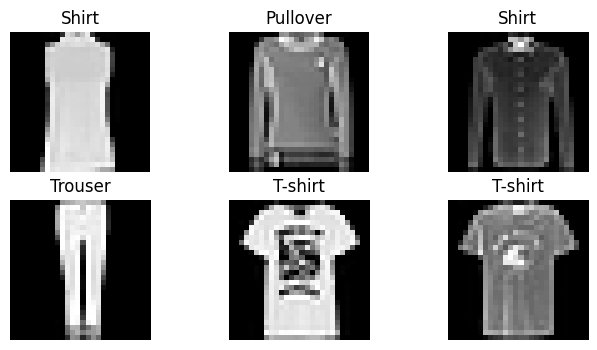

In [18]:
# Visualize Data

labels = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def show_images(images, labels_idx):
    plt.figure(figsize=(8, 4))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i][0], cmap='gray')
        plt.title(labels[labels_idx[i]])
        plt.axis('off')
    plt.show()

X, y = next(iter(train_loader))
show_images(X, y)

In [19]:
# Model: Softmax Regression

num_inputs = 28 * 28 # image size 28 * 28
num_outputs = 10 # There are 10 classes in this dataset

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

# Softmax stable
def softmax(X):
    X_shifted = X - X.max(dim=1, keepdim=True).values
    exp_X = torch.exp(X_shifted)
    return exp_X / exp_X.sum(dim=1, keepdim=True)

# Model
def net(X):
    X = X.reshape(-1, num_inputs)
    return softmax(X @ W + b)

# Loss
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]).mean()

# Accuracy
def accuracy(loader):
    correct, total = 0, 0
    for X, y in loader:
        y_hat = net(X)
        pred = y_hat.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

In [20]:
# Training loop

lr = 0.1
epochs = 20

train_losses = []
test_accs = []

for epoch in range(epochs):
    if(epoch < 10):
        lr = 0.1
    else:
        lr = 0.01

    total_loss = 0

    for X, y in train_loader:
        y_hat = net(X)
        loss = cross_entropy(y_hat, y)

        loss.backward()

        with torch.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad
            W.grad.zero_()
            b.grad.zero_()

        total_loss += loss.item()

    acc = accuracy(test_loader)

    train_losses.append(total_loss)
    test_accs.append(acc)

    print(f"Epoch {epoch + 1}, Loss {total_loss:.2f}, Test Acc {acc:.4f}")


Epoch 1, Loss 585.36, Test Acc 0.8168
Epoch 2, Loss 459.12, Test Acc 0.8032
Epoch 3, Loss 435.79, Test Acc 0.8162
Epoch 4, Loss 423.39, Test Acc 0.8142
Epoch 5, Loss 414.06, Test Acc 0.8248
Epoch 6, Loss 408.32, Test Acc 0.8388
Epoch 7, Loss 403.08, Test Acc 0.8390
Epoch 8, Loss 398.92, Test Acc 0.8349
Epoch 9, Loss 395.89, Test Acc 0.8156
Epoch 10, Loss 391.78, Test Acc 0.8368
Epoch 11, Loss 371.90, Test Acc 0.8443
Epoch 12, Loss 371.01, Test Acc 0.8439
Epoch 13, Loss 370.61, Test Acc 0.8452
Epoch 14, Loss 370.47, Test Acc 0.8444
Epoch 15, Loss 370.17, Test Acc 0.8442
Epoch 16, Loss 369.71, Test Acc 0.8453
Epoch 17, Loss 369.65, Test Acc 0.8439
Epoch 18, Loss 369.34, Test Acc 0.8447
Epoch 19, Loss 369.07, Test Acc 0.8432
Epoch 20, Loss 368.85, Test Acc 0.8441


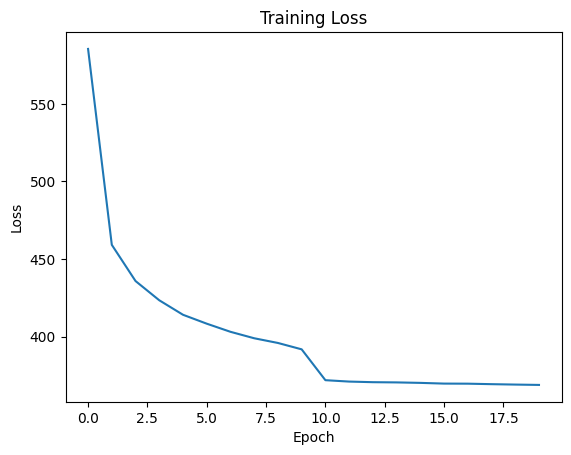

In [21]:
# Loss Curve
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

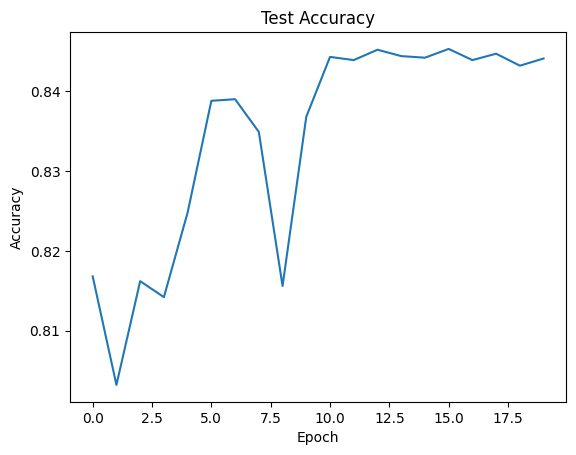

In [22]:
# Accuracy curve
plt.plot(test_accs)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

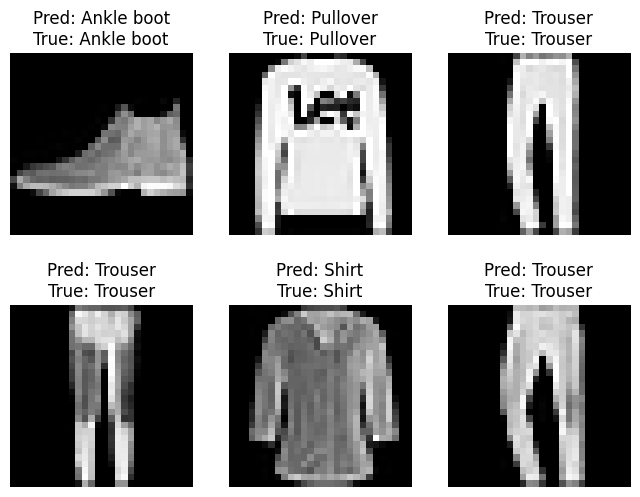

In [25]:
def show_predictions():
    X, y = next(iter(test_loader))
    y_hat = net(X)
    preds = y_hat.argmax(dim=1)

    plt.figure(figsize=(8, 6))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(X[i][0], cmap='gray')
        plt.title(f"Pred: {labels[preds[i]]}\nTrue: {labels[y[i]]}")
        plt.axis('off')
    plt.show()

show_predictions()

In this project, I implemented a softmax regression model from scratch using PyTorch to perform image classification on the FashionMNIST dataset. The results show that:


The training loss consistently decreases over epochs, indicating that the model successfully learns meaningful patterns from the data and converges properly.


The test accuracy improves over time and stabilizes around 84–85%, which is expected for a linear classifier without hidden layers.


The accuracy curve shows noticeable fluctuations across epochs. This is due to the stochastic nature of mini-batch gradient descent, where each update is based on a small subset of the data, introducing noise into the optimization process.


Applying a learning rate schedule (reducing the learning rate after epoch 10) improves stability and leads to better convergence, as reflected by smoother accuracy behavior in later epochs.


The model does not show strong signs of overfitting, as the performance remains relatively stable on the test set.


Overall, the model demonstrates a correct implementation of the softmax classification pipeline, including forward pass, loss computation, and parameter updates, and provides a solid understanding of how linear classifiers perform on real-world image data.